# Выполнение работы по "Лекция: Domain Shift + Наивный Байес + Метрики (демо + домашка)" от Зейналов У.Р.

## Часть A — Domain shift и различия распределений
- Смотрим, как меняются распределения текста между **темами / жанрами / стилями**
- Используем **log-odds** (лог-отношение вероятностей) для поиска токенов, которые лучше всего различают домены
- Заглядываем в несколько классических датасетов

## Часть B — Наивный байесовский классификатор и оценка качества
- Строим **классификатор авторов** на публичных текстах (Project Gutenberg)
- Обучаем **Multinomial Naive Bayes** (на counts), сравниваем с **TF-IDF + NB**
- Считаем метрики: accuracy, precision/recall/F1, macro vs micro
- Делаем **domain shift**: обучаем на прозе, тестируем на поэзии (те же авторы)




##УСТАНОВКА

In [40]:
!pip install datasets pymorphy3 scikit-learn matplotlib

##Библиотеки


In [41]:
from datasets import load_dataset
import re
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## ЗАГРУЗКА ДАТАСЕТА

In [42]:
ds = load_dataset("data-silence/rus_news_classifier")

print(ds)
print(ds["train"].column_names)
print(ds["train"][0])

DatasetDict({
    train: Dataset({
        features: ['news', 'labels'],
        num_rows: 57530
    })
    test: Dataset({
        features: ['news', 'labels'],
        num_rows: 14383
    })
})
['news', 'labels']
{'news': 'Житель Москвы сходил на сеанс эротического массажа, после которого умер. Об этом сообщает Telegram-канал Mash. По информации издания, 31-летний москвич заказывал сеанс массажа с последующими интимными услугами в квартире на бульваре Яна Райниса. Через некоторое время тело мужчины обнаружили в ванной. Жители дома рассказали полиции, что квартира сдавалась посуточно, и в ней регулярно проходили не только аналогичные сеансы, но и вечеринки, сообщает канал. Точную причину смерти москвича определят следователи. Ранее трое жителей Чечни, чьи личности не раскрываются, пропали после оргии в Грозном. Во время вечеринки компания из четырех человек активно снимала видео, в том числе процесс употребления неизвестного порошка.', 'labels': 1}


In [43]:
cols = ds["train"].column_names
sample = ds["train"][0]

print("Колонки:", cols)
print("Пример:", sample)

text_col = None
label_col = None

for c in cols:
    if isinstance(sample[c], str):
        if text_col is None:
            text_col = c
        else:
            label_col = c

if label_col is None:
    for c in cols:
        if c != text_col:
            label_col = c
            break

print("Text column:", text_col)
print("Label column:", label_col)

texts = ds["train"][text_col]
labels = ds["train"][label_col]

Колонки: ['news', 'labels']
Пример: {'news': 'Житель Москвы сходил на сеанс эротического массажа, после которого умер. Об этом сообщает Telegram-канал Mash. По информации издания, 31-летний москвич заказывал сеанс массажа с последующими интимными услугами в квартире на бульваре Яна Райниса. Через некоторое время тело мужчины обнаружили в ванной. Жители дома рассказали полиции, что квартира сдавалась посуточно, и в ней регулярно проходили не только аналогичные сеансы, но и вечеринки, сообщает канал. Точную причину смерти москвича определят следователи. Ранее трое жителей Чечни, чьи личности не раскрываются, пропали после оргии в Грозном. Во время вечеринки компания из четырех человек активно снимала видео, в том числе процесс употребления неизвестного порошка.', 'labels': 1}
Text column: news
Label column: labels


In [44]:
# НАЗВАНИЯ КЛАССОВ
if hasattr(ds["train"].features[label_col], "names"):
    label_names = ds["train"].features[label_col].names
else:
    label_names = list(set(labels))

print(label_names)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


##ВЫБОР ДОМЕНОВ
Выбраны темы политика и экологии.

In [45]:
topic1 = label_names[0]
topic2 = label_names[1]

print(topic1, topic2)

if isinstance(labels[0], int):
    i1 = label_names.index(topic1)
    i2 = label_names.index(topic2)

    texts_1 = [t for t, y in zip(texts, labels) if y == i1]
    texts_2 = [t for t, y in zip(texts, labels) if y == i2]
else:
    texts_1 = [t for t, y in zip(texts, labels) if y == topic1]
    texts_2 = [t for t, y in zip(texts, labels) if y == topic2]

print(len(texts_1), len(texts_2))

0 1
3712 6277


## ТОКЕНИЗАЦИЯ

In [46]:
def simple_tokenize(text):
    return re.findall(r"\b\w+\b", text.lower())

## LOG-ODDS

In [47]:
def top_log_odds_words(texts1, texts2, top_n=30, alpha=0.1):
    c1 = Counter()
    c2 = Counter()

    for t in texts1:
        c1.update(simple_tokenize(t))
    for t in texts2:
        c2.update(simple_tokenize(t))

    vocab = set(c1.keys()) | set(c2.keys())

    total1 = sum(c1.values())
    total2 = sum(c2.values())

    scores = {}

    for w in vocab:
        p1 = (c1[w] + alpha) / (total1 + alpha * len(vocab))
        p2 = (c2[w] + alpha) / (total2 + alpha * len(vocab))
        scores[w] = np.log(p1 / p2)

    sorted_words = sorted(scores.items(), key=lambda x: x[1], reverse=True)

    return sorted_words[:top_n], sorted_words[-top_n:]

## ТОП СЛОВА

In [48]:
pos, neg = top_log_odds_words(texts_1[:2000], texts_2[:2000])

print("TOP для", topic1)
display(pd.DataFrame(pos, columns=["word", "score"]))

print("TOP для", topic2)
display(pd.DataFrame(neg, columns=["word", "score"]))

TOP для 0


,word,score
0,выбросов,8.344678
1,вильфанд,7.622633
2,газов,7.393668
3,парниковых,7.353278
4,природы,7.311189
5,углекислого,7.250262
6,гидрометцентра,7.141788
7,леопарда,7.034374
8,климатической,6.945492
9,ископаемого,6.945492


TOP для 1


,word,score
0,иг,-6.755820
1,цахал,-6.755820
2,больнице,-6.770188
3,силовики,-6.770188
4,военного,-6.784353
5,сво,-6.784353
6,подозрению,-6.798319
7,афганистана,-6.865368
8,f,-6.878255
9,стрельбу,-6.890978


## ГРАФИК 1 — ДЛИНА ТЕКСТОВ

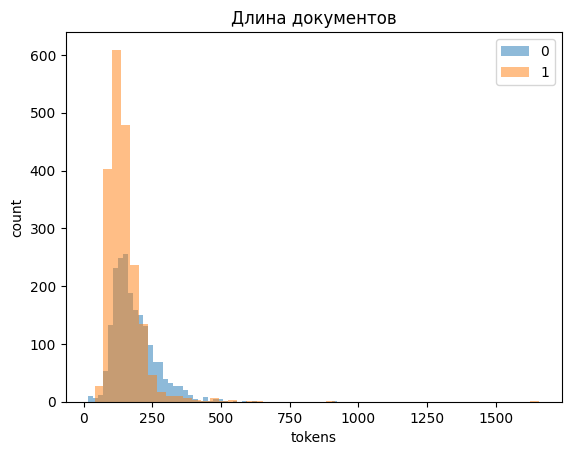

In [49]:
len1 = [len(simple_tokenize(t)) for t in texts_1[:2000]]
len2 = [len(simple_tokenize(t)) for t in texts_2[:2000]]

plt.figure()
plt.hist(len1, bins=50, alpha=0.5, label=topic1)
plt.hist(len2, bins=50, alpha=0.5, label=topic2)

plt.legend()
plt.title("Длина документов")
plt.xlabel("tokens")
plt.ylabel("count")
plt.show()

## ГРАФИК 2 — ЗАКОН ЦИПФА

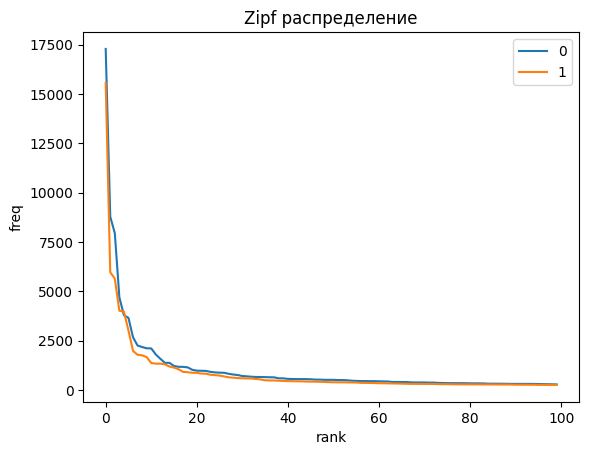

In [50]:
def plot_zipf(texts, label):
    tokens = []
    for t in texts[:2000]:
        tokens.extend(simple_tokenize(t))

    cnt = Counter(tokens)
    freqs = sorted(cnt.values(), reverse=True)[:100]

    plt.plot(freqs, label=label)

plt.figure()
plot_zipf(texts_1, topic1)
plot_zipf(texts_2, topic2)

plt.legend()
plt.title("Zipf распределение")
plt.xlabel("rank")
plt.ylabel("freq")
plt.show()

## ЛЕММАТИЗАЦИЯ


In [39]:
import pymorphy3
morph = pymorphy3.MorphAnalyzer()

def lemmatize(text):
    return " ".join([morph.parse(w)[0].normal_form for w in simple_tokenize(text)])

texts_1_lem = [lemmatize(t) for t in texts_1[:1000]]
texts_2_lem = [lemmatize(t) for t in texts_2[:1000]]

pos_lem, neg_lem = top_log_odds_words(texts_1_lem, texts_2_lem)

print("LEMMA TOP для", topic1)
display(pd.DataFrame(pos_lem, columns=["word", "score"]))

print("LEMMA TOP для", topic2)
display(pd.DataFrame(neg_lem, columns=["word", "score"]))

LEMMA TOP для 0


,word,score
0,выброс,8.302694
1,природа,7.247012
2,парниковый,7.060251
3,вильфанда,6.959519
4,снег,6.905073
5,цельсий,6.897048
6,вредный,6.777349
7,углекислый,6.711659
8,возобновлять,6.701913
9,углеродный,6.651701


LEMMA TOP для 1


,word,score
0,беспилотный,-6.402492
1,дальность,-6.402492
2,бпнуть,-6.443231
3,обыск,-6.462995
4,потерпевший,-6.482375
5,силовик,-6.501387
6,летательный,-6.520044
7,госпитализировать,-6.538360
8,израильский,-6.538360
9,вооружение,-6.608441


# Домашка

## Часть A — Domain shift / распределения
1) Выберите датасет на русском  языке и два домена (2 темы из одного датасета, или 2 датасета HF, или свои тексты. Вариант датасета: https://huggingface.co/datasets/data-silence/rus_news_classifier).
2) Посчитайте **top-30 log-odds** токенов (в обе стороны).
3) Нарисуйте хотя бы 2 графика распределений (на выбор):
   - длина документов,
   - Zipf (частоты топ-100 токенов),
   - доля чисел/пунктуации,
   - размер словаря.
4) добавьте лемматизацию, n-граммы, стоп-слова, и сравните важные токены.
5) Напишите 5–10 наблюдений: что изменилось и почему.

## Часть B — Наивный Байес + оценка
1) Выберите 2 автора (русский).
2) Нарежьте тексты на чанки (80–300 токенов).
3) Обучите MultinomialNB и отчитайтесь:
   - confusion matrix,
   - precision/recall/F1.
4) Покажите **top-20 важнейших токенов** на основе Δ(w).
5) добавьте лемматизацию, n-граммы, стоп-слова, и сравните важные токены.
6) Сделайте domain shift (например, проза → стихи / письма / пьесы) и опишите, что сломалось и что помогло.

